## Load in files

In [46]:
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
import numpy as np
import neurokit2 as nk
import bioread as bio
import pandas as pd
import dash
from dash import dcc, html, Input, Output
from scipy.ndimage import maximum_filter1d, minimum_filter1d, uniform_filter1d
from scipy.signal import (butter, envelope, filtfilt, find_peaks, hilbert, medfilt, sosfiltfilt, resample_poly, correlate, correlation_lags)
from scipy.interpolate import interp1d

ppg_files = [
    # r'C:\Users\a_hop\Documents\A1 Biopoint Watch Tests\02JUN2026 o2 tests\Amanda\ppg_finger.parquet',
    # r'C:\Users\a_hop\Documents\A1 Biopoint Watch Tests\02JUN2026 o2 tests\Amanda\ppg_wrist.parquet',
    # r'C:\Users\a_hop\Documents\A1 Biopoint Watch Tests\02JUN2026 o2 tests\Andrew\ppg_finger.parquet',
    # r'C:\Users\a_hop\Documents\A1 Biopoint Watch Tests\02JUN2026 o2 tests\Andrew\ppg_wrist.parquet',
    '/export02/users/ahope/o2_calibration_files/sub-2139/ppg.parquet',
    '/export02/users/ahope/o2_calibration_files/sub-2135/ppg.parquet',
    '/export02/users/ahope/o2_calibration_files/sub-2125/ppg.parquet',
]

spo2_files = [
    # r'C:\Users\a_hop\Documents\A1 Biopoint Watch Tests\02JUN2026 o2 tests\Amanda\finger.acq',
    # r'C:\Users\a_hop\Documents\A1 Biopoint Watch Tests\02JUN2026 o2 tests\Amanda\wrist.acq',
    # r'C:\Users\a_hop\Documents\A1 Biopoint Watch Tests\02JUN2026 o2 tests\Andrew\finger.acq',
    # r'C:\Users\a_hop\Documents\A1 Biopoint Watch Tests\02JUN2026 o2 tests\Andrew\wrist.acq',
    '/export02/projects/LCS/01_physio/sub-2139/ses-1/sub-2139_ses-1_task-gas_physio.acq',
    '/export02/projects/LCS/01_physio/sub-2135/ses-01/sub-2135_ses-1_task-gas_physio.acq',
    '/export02/projects/LCS/01_physio/sub-2125/ses-1/sub-2125_ses-1_task-gas_physio.acq'
]

## Functions

In [84]:
def calculate_ppg_ac(fs, ppg_pulse, method):
    if method == 'peak-to-peak':
        ppg_ac = np.zeros_like(ppg_pulse)

        ppg_peaks, _ = find_peaks(ppg_pulse, distance = fs*0.4)

        ppg_troughs, _ = find_peaks(-ppg_pulse, distance = fs*0.4)
        
        for i in range(len(ppg_peaks) - 1):
            p1 = ppg_peaks[i]
            p2 = ppg_peaks[i+1]

            prev_troughs = ppg_troughs[ppg_troughs < p1]

            if len(prev_troughs) == 0:
                continue

            t = prev_troughs[-1]
            
            amp = ppg_pulse[p1] - ppg_pulse[t]
            ppg_ac[p1:p2] = amp
    elif method == 'rms':
        block_sec = 8
        block_size = fs * block_sec
        ppg_pulse_sq = ppg_pulse**2
        ppg_ac = np.sqrt(
        np.convolve(
            ppg_pulse**2,
            np.ones(block_size) / block_size,
            mode='same'
        )
        )
    return ppg_ac

def block_average(x, block_size):
    n_blocks = len(x) // block_size

    x_trim = x[:n_blocks * block_size]
    blocks = x_trim.reshape(n_blocks, block_size)

    block_means = blocks.mean(axis=1)

    # expand back to original shape
    out = np.repeat(block_means, block_size)

    # handle leftover tail (keep same length as x)
    remainder = len(x) - len(out)
    if remainder > 0:
        tail_mean = x[n_blocks * block_size:].mean()
        out = np.concatenate([out, np.full(remainder, tail_mean)])

    return out
        


def plot_n_signals(title, time, signals, yaxis_labels, colors = None, xmin = None, xmax = None):

    num_rows = len(signals)
    pio.renderers.default = "browser" # opens in browser

    fig = make_subplots(rows=num_rows, cols=1, shared_xaxes=True,
    vertical_spacing=0.05)

    for i in range(num_rows):
        if colors is None:
            color = 'black'
        else:
            color = colors[i]
        
        if xmin is None:
            xmin = np.min(signals[i])
        if xmax is None:
            xmax = np.max(signals[i])
        fig.add_trace(go.Scatter(x=time, y=signals[i], name=yaxis_labels[i], line=dict(color=color)),
        row=i + 1, col=1)
        fig.update_yaxes(fixedrange=False, row=i + 1, col=1)
        fig.update_yaxes(title_text=yaxis_labels[i], range = [xmin, xmax], row=i + 1, col=1)
        #fig.update_xaxes(range=[0, 3*3600])
        if i ==0:
            fig.update_layout(xaxis_rangeslider_visible = False)
        elif i == num_rows - 1:
            fig.update_layout(**{
                f"xaxis{i+1}_rangeslider_visible": True
            })
        else:
            fig.update_layout(**{
                f"xaxis{i+1}_rangeslider_visible": False
            })
    # -----------------------------
    # Layout settings
    # -----------------------------
    fig.update_layout(
        height=600,
        width=1000,
        showlegend=False,
        title_text=title,
    )
    fig.show()
    return fig


# def calculate_ppg_ac(fs, ppg_pulse, method):
#     if method == 'peak-to-peak':
#         ppg_ac = np.zeros_like(ppg_pulse)

#         ppg_peaks, _ = find_peaks(ppg_pulse, distance = fs*0.4)

#         ppg_troughs, _ = find_peaks(-ppg_pulse, distance = fs*0.4)
        
#         for i in range(len(ppg_peaks) - 1):
#             p1 = ppg_peaks[i]
#             p2 = ppg_peaks[i+1]

#             prev_troughs = ppg_troughs[ppg_troughs < p1]

#             if len(prev_troughs) == 0:
#                 continue

#             t = prev_troughs[-1]
            
#             amp = ppg_pulse[p1] - ppg_pulse[t]
#             ppg_ac[p1:p2] = amp
#     elif method == 'rms':
#         block_sec = 8
#         block_size = fs * block_sec
#         ppg_pulse_sq = ppg_pulse**2
#         ppg_ac = np.sqrt(
#         np.convolve(
#             ppg_pulse**2,
#             np.ones(block_size) / block_size,
#             mode='same'
#         )
#         )

#     return ppg_ac

def block_average(x, block_size):
    n_blocks = len(x) // block_size

    x_trim = x[:n_blocks * block_size]
    blocks = x_trim.reshape(n_blocks, block_size)

    block_means = blocks.mean(axis=1)

    # expand back to original shape
    out = np.repeat(block_means, block_size)

    # handle leftover tail (keep same length as x)
    remainder = len(x) - len(out)
    if remainder > 0:
        tail_mean = x[n_blocks * block_size:].mean()
        out = np.concatenate([out, np.full(remainder, tail_mean)])

    return out
        


def plot_n_signals(title, time, signals, yaxis_labels, masks = None, colors = None, ymin = None, ymax = None):

    num_rows = len(signals)
    pio.renderers.default = "browser" # opens in browser

    fig = make_subplots(rows=num_rows, cols=1, shared_xaxes=True,
    vertical_spacing=0.05)

    for i in range(num_rows):
        if colors is None:
            color = 'black'
        else:
            color = colors[i]
        
        if ymin is None:
            ymin = np.min(signals[i])
        if ymax is None:
            ymax = np.max(signals[i])
        if masks is None:
            fig.add_trace(go.Scatter(x=time, y=signals[i], name=yaxis_labels[i], line=dict(color=color)),row=i + 1, col=1),
        else:
            mask = masks[i]
            if mask is None:
                fig.add_trace(go.Scatter(x=time, y=signals[i], name=yaxis_labels[i], line=dict(color=color)),row=i + 1, col=1),
            else:
                fig.add_trace(go.Scatter(x=time, y=signals[i], name=yaxis_labels[i], line=dict(color=color)),row=i + 1, col=1),
                fig.add_trace(go.Scatter(x = time[mask], y = signals[i][mask], line = dict(color = 'black'), mode = 'markers'),row=i + 1, col=1),
        fig.update_yaxes(fixedrange=False, row=i + 1, col=1)
        fig.update_yaxes(title_text=yaxis_labels[i], range = [ymin, ymax], row=i + 1, col=1)
        #fig.update_xaxes(range=[0, 3*3600])
        if i ==0:
            fig.update_layout(xaxis_rangeslider_visible = False)
        elif i == num_rows - 1:
            fig.update_layout(**{
                f"xaxis{i+1}_rangeslider_visible": True
            })
        else:
            fig.update_layout(**{
                f"xaxis{i+1}_rangeslider_visible": False
            })
    # -----------------------------
    # Layout settings
    # -----------------------------
    fig.update_layout(
        height=600,
        width=1000,
        showlegend=False,
        title_text=title,
    )
    fig.show()
    return fig


def plot_n_long_signals_dash(title, time, signals, yaxis_labels, colors=None, xmin=None, xmax=None):

    # Convert time once
    time_dt = pd.to_datetime(time)
    t_origin = time_dt.iloc[0]
    time_sec = (time_dt - t_origin).dt.total_seconds().to_numpy()
    signals_np = [s.to_numpy() if hasattr(s, 'to_numpy') else np.array(s) for s in signals]

    t_min = float(np.min(time_sec))
    t_max = float(np.max(time_sec))
    window = 1 * 3600
    starts = np.arange(t_min, t_max, window)
    num_rows = len(signals_np)

    app = dash.Dash(__name__)

    app.layout = html.Div([
        html.H3(title),
        dcc.Graph(id='graph', style={'height': '600px'}),
        html.Div([
            html.Label("Hour window:"),
            dcc.Slider(
                id='hour-slider',
                min=0,
                max=len(starts) - 1,
                step=1,
                value=0,
                marks={i: (t_origin + pd.Timedelta(seconds=s)).strftime('%H:%M')
                    for i, s in enumerate(starts)},
            )
        ], style={'padding': '20px'})
    ])

    @app.callback(
        Output('graph', 'figure'),
        Input('hour-slider', 'value')
    )
    def update_graph(slider_idx):
        start = starts[slider_idx]
        mask = (time_sec >= start) & (time_sec < start + window)
        t_win = time_dt[mask]

        fig = make_subplots(rows=num_rows, cols=1, shared_xaxes=True, vertical_spacing=0.05)

        for i, (sig, label) in enumerate(zip(signals_np, yaxis_labels)):
            color = 'black' if colors is None else colors[i]
            y_min = xmin if xmin is not None else float(np.min(sig))
            y_max = xmax if xmax is not None else float(np.max(sig))
            fig.add_trace(
                go.Scatter(x=t_win, y=sig[mask], name=label, line=dict(color=color)),
                row=i + 1, col=1
            )
            fig.update_yaxes(title_text=label, range=[y_min, y_max], fixedrange=False, row=i + 1, col=1)

        fig.update_layout(
            height=600, width=1000, showlegend=False,
            xaxis=dict(range=[t_win.iloc[0], t_win.iloc[-1]])
        )
        return fig

    app.run(debug=False)
    
def plot_n_long_signals(title, time, signals, yaxis_labels, colors=None, ymin=None, ymax=None, display_pts = 50000):

    pio.renderers.default = "browser"

    time_dt = pd.to_datetime(time)  # keep original datetimes for display
    t_origin = time_dt.iloc[0]
    time = (time_dt - t_origin).dt.total_seconds().to_numpy()
    signals = [s.to_numpy() if hasattr(s, 'to_numpy') else np.array(s) for s in signals]

    t_min = float(np.min(time))
    t_max = float(np.max(time))
    window = 1 * 3600
    starts = np.arange(t_min, t_max, window)
    num_rows = len(signals)

    def get_window(start):
        mask = (time >= start) & (time < start + window)
        t_win = time[mask]
        # convert back to datetime for display
        t_win_dt = t_origin + pd.to_timedelta(t_win, unit='s')
        sigs_win = [sig[mask] for sig in signals]
        step = max(1, len(t_win) // display_pts)
        return t_win_dt[::step], [s[::step] for s in sigs_win]

    fig = make_subplots(rows=num_rows, cols=1, shared_xaxes=True, vertical_spacing=0.05)

    t0, sigs0 = get_window(starts[0])
    for i, (sig, label) in enumerate(zip(sigs0, yaxis_labels)):
        color = 'black' if colors is None else colors[i]
        if ymin is None:
            ymin = np.min(sig)
        if ymax is None:
            ymax = np.max(sig)
        fig.add_trace(
            go.Scatter(x=t0, y=sig, name=label, line=dict(color=color)),
            row=i + 1, col=1
        )
        fig.update_yaxes(title_text=label, range = [ymin, ymax], row=i + 1, col=1)


    frames = []
    for start in starts:
        t_win_dt, sigs_win = get_window(start)
        t_start_dt = t_origin + pd.Timedelta(seconds=start)
        t_end_dt = t_origin + pd.Timedelta(seconds=start + window)
        frames.append(go.Frame(
            data=[go.Scatter(x=t_win_dt, y=s) for s in sigs_win],
            traces=list(range(num_rows)),
            name=str(int(start)),
            layout=go.Layout(xaxis=dict(range=[t_start_dt, t_end_dt]))
        ))
    fig.frames = frames

    slider_steps = [
        dict(
            method="animate",
            label=(t_origin + pd.Timedelta(seconds=s)).strftime('%H:%M'),
            args=[[str(int(s))], {"frame": {"duration": 0, "redraw": True}, "mode": "immediate", "transition": {"duration": 0}}]
        )
        for s in starts
    ]

    fig.update_layout(
        height=600, width=1000, showlegend=False, title_text=title,

        sliders=[dict(
            active=0,
            currentvalue=dict(prefix="Window: ", visible=True, xanchor="center"),
            pad=dict(t=50),
            steps=slider_steps
        )]
    )

    fig.show()
    return fig


def add_hr_quality(times, ppg_peaks, window_sec = 10):

    HR_time_points = times[ppg_peaks]

    HR_col = np.full(len(times), np.nan)
    HR_quality_col = np.full(len(times), '', dtype=object)

    i = 0

    while i < len(times):
        t_start = times[i]
        t_end = t_start + np.timedelta64(window_sec, 's')

        #Samples in current window
        sample_idx = (times >= t_start) & (times < t_end)


        #Peaks in current window
        peak_idx = (HR_time_points >= t_start) & (HR_time_points < t_end)
        time_chunk = HR_time_points[peak_idx]

        if len(time_chunk) > 1:
            diffs = np.diff(time_chunk)
            HR_intervals = diffs / np.timedelta64(1, 's')

            #Rules
            three_sec_rule = np.all(HR_intervals < 3)

            HR = len(time_chunk)* 60 / window_sec

            HR_rule = 40 < HR < 180

            HR_ratio_rule = (np.max(HR_intervals)/ np.min(HR_intervals) < 2.2)

            quality = (
                1 
                if (three_sec_rule and HR_rule and HR_ratio_rule)
                else 0
            )
        else:
            HR = 0
            quality = 0
        
        #Assign window HR and quality for all samples
        HR_col[sample_idx] = HR
        HR_quality_col[sample_idx] = quality

        next_idx = np.where (times >= t_end)[0]
        if len(next_idx) == 0:
            break
        i = next_idx[0]
    return HR_col, HR_quality_col
    
            

## Calculations

In [85]:
df_ppgs = []
for i in range(len(ppg_files)):
    ppg_file = ppg_files[i]

    # Read ppg file
    df_ppg = pd.read_parquet(ppg_file)

    if "sub-green_ses-1_task-finger-overnight_biopoint" in ppg_file:
        df_ppg = df_ppg.iloc[::2].reset_index(drop=True)
        
    #Apply DC Filter
    fs = 50 # sampling rate (Hz) — change if needed
    fc_low_hp = 0.5 # cutoff frequency (Hz)
    order = 2 # biquad
    sos_lp = butter(N = order, Wn = fc_low_hp, btype = 'low', fs = fs, output = 'sos')

    ppg_dc_r = sosfiltfilt(sos_lp, df_ppg['r'])
    ppg_dc_ir = sosfiltfilt(sos_lp, df_ppg['ir'])
    ppg_dc_g = sosfiltfilt(sos_lp, df_ppg['g'])

    df_ppg['dc_r'] = ppg_dc_r
    df_ppg['dc_ir'] = ppg_dc_ir
    df_ppg['dc_g'] = ppg_dc_g

    df_ppg['dc_ratio'] = ppg_dc_r/ppg_dc_ir
    df_ppg['dc_ratio'] = df_ppg['dc_ratio'].replace([np.inf, -np.inf], np.nan)
    df_ppg['dc_ratio']  = df_ppg['dc_ratio'].interpolate(method = 'linear', limit = 5, limit_direction = 'both')

    #Apply AC filter
    fc_high = 0.5 # cutoff frequency (Hz)
    fc_low_ac = 8 # cutoff frequency (Hz)
    sos_hp = butter(N = order, Wn = fc_high, btype = 'high', fs = fs, output = 'sos')
    sos_lp_ac = butter(N = order, Wn = fc_low_ac, btype = 'low', fs = fs, output = 'sos')

    #Apply IMPROV filter MOM
    ppg_hp_r = sosfiltfilt(sos_hp, df_ppg['r'])
    ppg_hp_ir = sosfiltfilt(sos_hp, df_ppg['ir'])
    ppg_hp_g = sosfiltfilt(sos_hp, df_ppg['g'])

    ppg_pulse_r = sosfiltfilt(sos_lp_ac, ppg_hp_r)
    ppg_pulse_ir = sosfiltfilt(sos_lp_ac, ppg_hp_ir)
    ppg_pulse_g = sosfiltfilt(sos_lp_ac, ppg_hp_g)

    df_ppg['pulse_r'] = ppg_pulse_r
    df_ppg['pulse_ir'] = ppg_pulse_ir
    df_ppg['pulse_g'] = ppg_pulse_g

    ppg_ac_r = calculate_ppg_ac(fs, ppg_pulse_r, 'rms')
    ppg_ac_ir = calculate_ppg_ac(fs, ppg_pulse_ir, 'rms')
  
    df_ppg['ac_r'] = ppg_ac_r
    df_ppg['ac_ir'] = ppg_ac_ir

    df_ppg['ac_ratio'] = ppg_ac_r/ppg_ac_ir
    df_ppg['ac_ratio'] = df_ppg['ac_ratio'].replace([np.inf, -np.inf], np.nan)
    df_ppg['ac_ratio']  = df_ppg['ac_ratio'].interpolate(method = 'linear', limit = 5, limit_direction = 'both')

    df_ppg['r_ratio'] = (ppg_ac_r/ppg_dc_r)/(ppg_ac_ir/ppg_dc_ir)
    df_ppg['r_ratio'] = df_ppg['r_ratio'].replace([np.inf, -np.inf], np.nan)
    df_ppg['r_ratio']  = df_ppg['r_ratio'].interpolate(method = 'linear', limit = 5, limit_direction = 'both')


    #df_ppg['r_qual'] = nk.ppg_quality(ppg_ac_r,  sampling_rate = 50, method = 'ho2025')
    ppg_time = np.linspace(0,len(df_ppg['ir']) / fs,num=len(df_ppg['ir']),endpoint=False)
    df_ppg['time'] = ppg_time

    df_ppg['perfusion_index_r'] = ppg_ac_r/ppg_dc_r
    df_ppg['perfusion_index_ir'] = ppg_ac_ir/ppg_dc_ir


    ppg_smooth_r = uniform_filter1d(ppg_pulse_r, size=int(fs*0.1))  # 100ms smooth
    ppg_peaks_r, _ = find_peaks(ppg_smooth_r, distance=fs*0.4, prominence=0.1 * np.std(ppg_pulse_r))

    ppg_smooth_ir = uniform_filter1d(ppg_pulse_ir, size=int(fs*0.1))  # 100ms smooth
    ppg_peaks_ir, _ = find_peaks(ppg_smooth_ir, distance=fs*0.4, prominence=0.1 * np.std(ppg_pulse_ir))

    ppg_smooth_g = uniform_filter1d(ppg_pulse_g, size=int(fs*0.1))  # 100ms smooth
    ppg_peaks_g, _ = find_peaks(ppg_smooth_g, distance=fs*0.4, prominence=0.1 * np.std(ppg_pulse_g))

    df_ppg["peaks_r"] = df_ppg.index.isin(ppg_peaks_r).astype(int)
    df_ppg["peaks_ir"] = df_ppg.index.isin(ppg_peaks_ir).astype(int)
    df_ppg["peaks_g"] = df_ppg.index.isin(ppg_peaks_g).astype(int)

    times = df_ppg['datetime'].to_numpy()

    df_ppg['HR_r'], df_ppg['HR_quality_r'] = add_hr_quality(df_ppg['datetime'], ppg_peaks_r, window_sec = 5)
    df_ppg['HR_ir'], df_ppg['HR_quality_ir'] = add_hr_quality(df_ppg['datetime'], ppg_peaks_ir, window_sec = 5)

    
    # Get baseline
    r_baseline = df_ppg['r_ratio'].rolling(window=60*fs, center=True).median()  # very slow trend
    
    #Get deviation from baseline
    r_deviation = np.abs(df_ppg['r_ratio'] - r_baseline)
    df_ppg['r_ratio_deviation'] = r_deviation

    lockout_sec = 20  
    lockout_samples = lockout_sec * fs

    #Filter out 20s around identified spikes
    spike_mask = pd.Series(r_deviation > 0.1, index=df_ppg.index)
    spike_mask = spike_mask.rolling(window=lockout_samples, center=True).max().astype(bool)
    df_ppg['r_ratio_quality'] = ~spike_mask

    #SPO2 processing
    spo2_file = spo2_files[i]
    spo2_acq = bio.read_file(spo2_file)

    # Read spo2 file
    spo2_data = spo2_acq.channels[0]
    if len(spo2_acq.event_markers) > 1:
        start_marker_index = spo2_acq.event_markers[1].sample_index    
        spo2_data_aligned = spo2_data.data[start_marker_index:]
    else:
        spo2_data_aligned = spo2_data.data

    #downsample spo2
    spo2_downsampled = resample_poly(spo2_data_aligned, up=1, down=5)

    #align time axes
    n = min(len(df_ppg), len(spo2_downsampled))
    df_ppg_trimmed = df_ppg.iloc[:n]
    spo2_trimmed = spo2_downsampled[:n]

    if i != 2:
        def normalize(x):
            return (x - np.mean(x)) / np.std(x)
        corr = correlate(normalize(spo2_trimmed), normalize(df_ppg_trimmed['r_ratio']), mode='full')
        best_lag = np.argmin(corr) - (len(df_ppg_trimmed) - 1)

        ##Cross correlate to align signals to one another
        if best_lag > 0:
            spo2_aligned   = spo2_trimmed[best_lag:]
            df_ppg_aligned = df_ppg_trimmed.iloc[:len(spo2_aligned)]
        else:
            df_ppg_aligned    = df_ppg_trimmed.iloc[-best_lag:]
            spo2_aligned   = spo2_trimmed[:len(df_ppg_aligned)]
        df_ppg_aligned['spo2'] = spo2_aligned
        df_ppgs.append(df_ppg_aligned)
    else:
        df_ppg_trimmed['spo2'] = spo2_trimmed
        df_ppgs.append(df_ppg_trimmed)





    

/tmp/ipykernel_2693319/4019436297.py:138: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ppg_aligned['spo2'] = spo2_aligned
/tmp/ipykernel_2693319/4019436297.py:138: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ppg_aligned['spo2'] = spo2_aligned
/tmp/ipykernel_2693319/4019436297.py:141: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/panda

## Plot - GENERAL

In [106]:
current_ppg = df_ppgs[1]

#mins = 4
#start = current_ppg['datetime'].iloc[0]
#end = start + pd.Timedelta(minutes=mins)
#current_ppg = current_ppg[current_ppg['datetime'] <= end]
time = current_ppg['datetime']



In [29]:
# PLOT PULSATILE
signals = [current_ppg['pulse_g'], current_ppg['pulse_ir'], current_ppg['pulse_r']]
yaxis_labels = ['Pulse G', 'Pulse IR', 'Pulse R']
colors = ['green', 'purple', 'red']
fig = plot_n_signals('Ratios', time, signals, yaxis_labels, colors = colors, ymin = 0, ymax = 2)


In [87]:
# AC/DC RATIOS
signals = [current_ppg['ac_ratio'], current_ppg['dc_ratio'], current_ppg['r_ratio']]
yaxis_labels = ['AC Ratio', 'DC Ratio', 'R Ratio']
colors = ['green', 'purple', 'red']
fig = plot_n_signals('Ratios', time, signals, yaxis_labels, colors = colors, ymin = 0, ymax = 2)

# Plot - WRIST

In [88]:
# HR QUALITY R
signals = [current_ppg['pulse_r'], current_ppg['HR_quality_r'], current_ppg['HR_r']]
masks = [(current_ppg['peaks_r'] == 1), None, None]
yaxis_labels = ['Peak R', 'HR Qual R','HR R']
colors = ['red', 'green', 'purple']
fig = plot_n_signals('Pulses', time, signals, yaxis_labels, masks= masks , colors = colors)


In [ ]:
# HR QUALITY IR
signals = [current_ppg['pulse_ir'], current_ppg['HR_quality_ir'], current_ppg['HR_ir']]
masks = [(current_ppg['peaks_ir'] == 1), None, None]
yaxis_labels = ['Peak IR', 'HR Qual IR','HR IR']
colors = ['red', 'green', 'purple']
fig = plot_n_signals('Pulses', time, signals, yaxis_labels, masks= masks , colors = colors)



In [98]:
# R DEVIATION
signals = [current_ppg['r_ratio_quality'], current_ppg['r_ratio']]
masks = [ None, current_ppg['r_ratio_quality']]
yaxis_labels = ['R Ratio Quality','R Ratio']
colors = [ 'black', 'green']
fig = plot_n_signals('Pulses', time, signals, yaxis_labels, masks= masks , colors = colors)



In [156]:
#PERFUSION INDEX
perfusion_index_thresh = 0.013
signals = [current_ppg['pulse_r'],current_ppg['perfusion_index_r'], current_ppg['pulse_ir'], current_ppg['perfusion_index_ir']]
#masks = [None, None, None, None]

masks = [(current_ppg['perfusion_index_r']*100 >perfusion_index_thresh),(current_ppg['perfusion_index_ir']*100 >perfusion_index_thresh) ]
yaxis_labels = ['Pulse R', 'Pulse IR', 'Pulse R', 'Pulse IR']
colors = ['red', 'purple', 'red', 'purple']
fig = plot_n_signals('Pulses', time, signals, yaxis_labels, masks= masks , colors = colors)


In [74]:
#FINAL MASK
signals = [current_ppg['r_ratio'], current_ppg['spo2']]
masks = [(current_ppg['HR_quality_r'] == 1) & (current_ppg['HR_quality_ir'] == 1) & (current_ppg['spo2'] > 70 ) & (current_ppg['spo2'] < 100 )& (current_ppg['r_ratio_quality']), None]
yaxis_labels = ['R Ratio', 'SPO2']
colors = ['green', 'red']
fig = plot_n_signals('Pulses', time, signals, yaxis_labels, masks= masks , colors = colors)

In [107]:
current_ppg_filt = current_ppg[(current_ppg['HR_quality_r'] == 1) & (current_ppg['HR_quality_ir'] == 1) & (current_ppg['spo2'] > 70 ) & (current_ppg['spo2'] < 100 )& (current_ppg['r_ratio_quality'])]
current_ppg_filt['spo2_bin'] = (current_ppg_filt['spo2'] * 2).round() / 2
calibration_grouped = (
    current_ppg_filt
    .groupby('spo2_bin')['r_ratio']
    .median()
    .reset_index()
)
#calibration_grouped = calibration_grouped[calibration_grouped['spo2_bin'] >=85]

/tmp/ipykernel_2693319/1070273214.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  current_ppg_filt['spo2_bin'] = (current_ppg_filt['spo2'] * 2).round() / 2


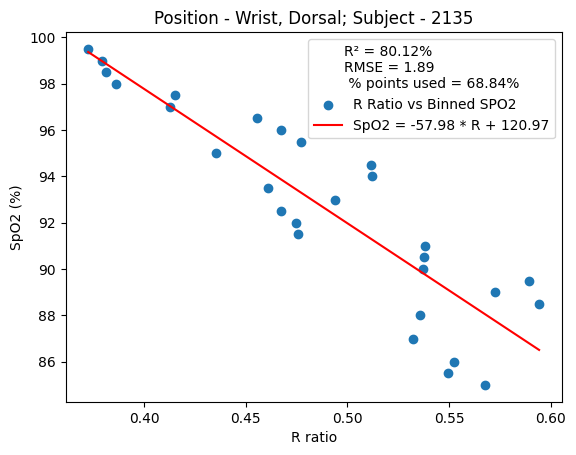

In [109]:
# fit
coeffs = np.polyfit(calibration_grouped['r_ratio'], calibration_grouped['spo2_bin'], deg=1)
a, b = coeffs

# plot
x = np.linspace(calibration_grouped['r_ratio'].min(), calibration_grouped['r_ratio'].max(), 100)
y = np.polyval(coeffs, x)

#Get standard error and RMSE
y_pred = np.polyval(coeffs, calibration_grouped['r_ratio'])
ss_res = np.sum((calibration_grouped['spo2_bin'] - y_pred)**2)
ss_tot = np.sum((calibration_grouped['spo2_bin'] - np.mean(calibration_grouped['spo2_bin']))**2)

n = len(calibration_grouped)
rmse = np.sqrt(ss_res / n)
r2 = (1 - (ss_res / ss_tot))*100

# Percent points useable
points_used = (len(current_ppg_filt)/ len(current_ppg))*100

plt.scatter(calibration_grouped['r_ratio'], calibration_grouped['spo2_bin'], label='R Ratio vs Binned SPO2')
plt.plot(x, y, color='red', label=f'SpO2 = {a:.2f} * R + {b:.2f}')
plt.xlabel('R ratio')
plt.ylabel('SpO2 (%)')
plt.legend(title=f'R² = {r2:.2f}%\nRMSE = {rmse:.2f}\n % points used = {points_used:.2f}%')
plt.title('Position - Wrist, Dorsal; Subject - 2135')
plt.show()

# Plot - Finger

In [20]:
#0 or 2
current_ppg = df_ppgs[0]
time = current_ppg['datetime']


In [21]:
# R RATIO vs SPO2
current_ppg['spo2_bin'] = current_ppg['spo2'].round(1)
calibration_grouped = current_ppg.groupby('spo2_bin')['r_ratio'].median().reset_index()

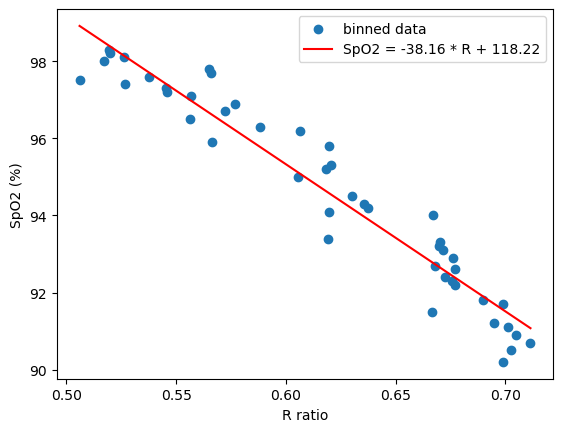

In [22]:
# fit
coeffs = np.polyfit(calibration_grouped['r_ratio'], calibration_grouped['spo2_bin'], deg=1)
a, b = coeffs

# plot
x = np.linspace(calibration_grouped['r_ratio'].min(), calibration_grouped['r_ratio'].max(), 100)
y = np.polyval(coeffs, x)

plt.scatter(calibration_grouped['r_ratio'], calibration_grouped['spo2_bin'], label='binned data')
plt.plot(x, y, color='red', label=f'SpO2 = {a:.2f} * R + {b:.2f}')
plt.xlabel('R ratio')
plt.ylabel('SpO2 (%)')
plt.legend()
plt.show()

## Plot - WRIST

In [22]:
# Wrist
current_ppg = df_ppgs[0]
time = current_ppg['datetime']

In [23]:
# PLOT PULSATILE 
signals = [current_ppg['r_ratio'], current_ppg['pulse_ir'], current_ppg['pulse_r']]
yaxis_labels = ['R Ratio', 'IR', 'R']
colors = ['green', 'purple', 'red']

# Plot - LONG

In [5]:
current_ppg = df_ppgs[6]
time = current_ppg['datetime']

In [8]:
# PLOT PULSATILE 
signals = [current_ppg['r_ratio'], current_ppg['pulse_ir'], current_ppg['pulse_r']]
yaxis_labels = ['R Ratio', 'IR', 'R']
colors = ['green', 'purple', 'red']
#n = 100000
fig = plot_n_long_signals_dash('Pulses', time, signals , yaxis_labels, colors, xmin = -50, xmax = 50)

In [19]:
# AC/DC RATIOS
signals = [current_ppg['ac_ratio'], current_ppg['dc_ratio'], current_ppg['r_ratio']]
yaxis_labels = ['AC Ratio', 'DC Ratio', 'R Ratio']
colors = ['green', 'purple', 'red']
fig = plot_n_long_signals_dash('Ratios', time, signals, yaxis_labels, colors, xmin = 0, xmax = 2)

In [ ]:
# Figure out HR quality


# Pulsatility

In [20]:
#Perfusion
lower = np.percentile(current_ppg['perfusion_index_r'], 5)
upper = np.percentile(current_ppg['perfusion_index_r'], 95)
filtered = current_ppg['perfusion_index_r'][(current_ppg['perfusion_index_r'] >= lower) & (current_ppg['perfusion_index_r'] <= upper)]

mean_perfusion_r = np.mean(filtered)*100

lower = np.percentile(current_ppg['perfusion_index_ir'], 5)
upper = np.percentile(current_ppg['perfusion_index_ir'], 95)
filtered = current_ppg['perfusion_index_ir'][(current_ppg['perfusion_index_ir'] >= lower) & (current_ppg['perfusion_index_ir'] <= upper)]
mean_perfusion_ir = np.mean(current_ppg['perfusion_index_ir'])*100
print(mean_perfusion_r)
print(mean_perfusion_ir)

0.31665458110371586
0.5242528802137743


In [72]:
import plotly.graph_objects as go
import numpy as np

t = np.linspace(0, 100, 1000)
fig = go.Figure()
fig.add_trace(go.Scatter(x=t, y=np.sin(t)))
fig.show()